## Figure 2 - Behavioral performance across experience

This script generates Figure 2, showing behavior metrics
across experience levels (Familiar, Novel, Novel+) including d-prime, hit rate,
response latency, running speed, pupil width, and lick rate.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.utilities as vbu
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

%load_ext autoreload
%autoreload 2
%matplotlib inline

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.p

In [2]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_2')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
platform_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_behavior_sessions_table.csv'), index_col=0)
platform_ophys_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_ophys_behavior_sessions_table.csv'), index_col=0)

# save to more convenient name
behavior_sessions = platform_behavior_sessions.copy()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

In [4]:
print(len(behavior_sessions.mouse_id.unique()), 'mice')
print(len(behavior_sessions.index.unique()), 'behavior sessions')


66 mice
2942 behavior sessions


In [5]:
print(len(platform_ophys_behavior_sessions.mouse_id.unique()), 'mice')
print(len(platform_ophys_behavior_sessions.ophys_experiment_id.unique()), 'experiments')
print(len(platform_ophys_behavior_sessions.ophys_session_id.unique()), 'ophys sessions')
print(len(platform_ophys_behavior_sessions.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


### Multi-session dataframes for behavior variables

In [6]:
# # Set params
# interpolate = False
# output_sampling_rate = 30
# inclusion_criteria = 'platform_experiment_table'

# # Running speed
# event_type = 'all'
# data_type = 'running_speed'
# conditions = ['ophys_experiment_id', 'is_change']
# running_speed_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria,
#                                                                interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                epoch_duration_mins=None)
# running_speed_mdf_changes = running_speed_mdf[running_speed_mdf.is_change == True]
# running_speed_mdf_changes = running_speed_mdf_changes.drop_duplicates(subset='behavior_session_id')

# # Running speed - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# running_speed_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                        epoch_duration_mins=5)
# running_speed_mdf_changes_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == True]
# running_speed_mdf_images_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == False]

# # Pupil width
# data_type = 'pupil_width'
# conditions = ['ophys_experiment_id', 'is_change']
# full_pupil_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                             interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                             epoch_duration_mins=None)
# pupil_mdf = full_pupil_mdf[full_pupil_mdf.is_change == True]
# pupil_mdf = pupil_mdf.drop_duplicates(subset='behavior_session_id')
# pupil_mdf = pupil_mdf[pupil_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Pupil width - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# pupil_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                               interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                               epoch_duration_mins=5)
# pupil_mdf_changes_epochs = pupil_mdf_epochs[pupil_mdf_epochs.is_change == True]

# # Lick rate
# data_type = 'lick_rate'
# conditions = ['ophys_experiment_id', 'is_change']
# lick_rate_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                            interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                            epoch_duration_mins=None)
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.is_change == True]
# lick_rate_mdf = lick_rate_mdf.drop_duplicates(subset='behavior_session_id')
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Lick rate - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# lick_rate_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                   interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                   epoch_duration_mins=5)
# lick_rate_mdf_changes_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == True]
# lick_rate_mdf_images_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == False]

### Behavior metrics

In [7]:
behavior_metrics_dir = loading.get_performance_metrics_dir()

# Behavior metrics computed by AllenSDK
behavior_stats_sdk = pd.read_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'), key='data')
behavior_stats_sdk.index.name = 'behavior_session_id'
columns = ['mouse_id', 'cre_line', 'cell_type', 'experience_level', 'session_type', 'behavior_session_id']
behavior_stats_sdk = behavior_stats_sdk.merge(behavior_sessions.reset_index()[columns], on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_sdk = behavior_stats_sdk[behavior_stats_sdk.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
behavior_stats_sdk['mouse_id'] = [int(mouse_id) for mouse_id in behavior_stats_sdk.mouse_id.values]

# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
engaged_behavior_stats_stim = pd.read_hdf(os.path.join(loading.get_platform_analysis_cache_dir(), 'stimulus_based_engaged_only_all_sessions.h5'), key='data')
engaged_behavior_stats_stim = engaged_behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
engaged_behavior_stats_stim = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
behavior_stats_stim = pd.read_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_all_sessions.h5'), key='data')
behavior_stats_stim = behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_stim = behavior_stats_stim[behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Load platform behavior stats for stimulus-based metrics
platform_behavior_stats = pd.read_csv(os.path.join(behavior_metrics_dir,  'platform_behavior_stats_engaged.csv'), index_col=0)
platform_behavior_stats = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
platform_behavior_stats = platform_behavior_stats[platform_behavior_stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


In [8]:
print(len(behavior_stats_sdk.mouse_id.unique()), 'mice')
print(len(behavior_stats_sdk.index.unique()), 'behavior sessions')


66 mice
202 behavior sessions


In [9]:
print(len(engaged_behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(engaged_behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(engaged_behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(engaged_behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


In [10]:
print(len(behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


## Plotting

### Panel A: Lick raster for Familiar/Novel/Novel+ comparison
Select example mouse with data at all experience levels

In [11]:
mouse_id = 425496

# Get datasets for each experience level
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id == mouse_id) &
                                             (platform_experiments.experience_level == 'Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

novel_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel') &
                                         (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel +') &
                                              (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

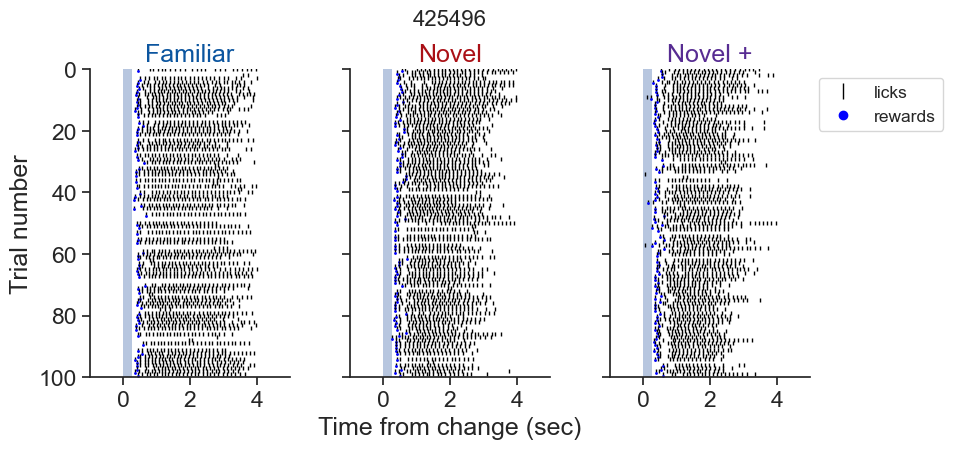

In [12]:

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', legend=True, ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

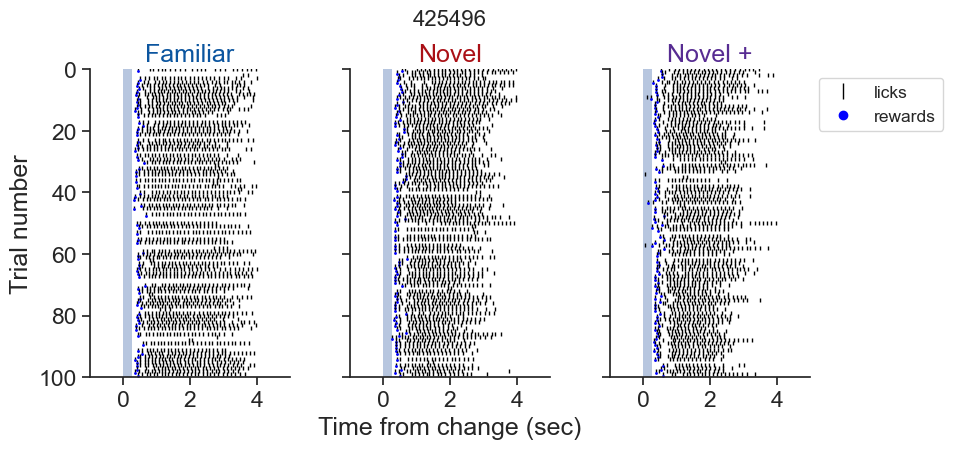

In [13]:

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', legend=True, ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

### Behavior performance

saving_stats


<Axes: ylabel='d-prime'>

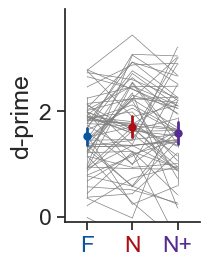

In [14]:
metric = 'max_dprime'
stats = behavior_stats_sdk.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='d-prime', ylims=[-0.1, 3.5],
                                      best_image=False, show_mice=True, plot_stats=True,
                                      stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

saving_stats


<Axes: ylabel='Response latency (s)'>

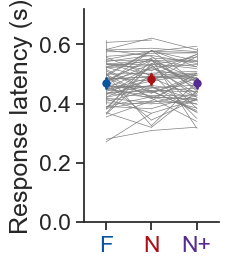

In [15]:
metric = 'response_latency_mean'
stats = behavior_stats_stim.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Response latency (s)', 
                                    ylims=None, show_mice=True, plot_stats=True, stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

### Event aligned behavior

#### Load dataframes for running, pupil, and licks, for both changes & omissions

In [16]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = None

# Running speed
running_speed_mdf_changes = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil width
pupil_mdf_changes = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Lick rate
lick_rate_mdf_changes = loading.get_behavior_multi_session_df('lick_rate', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_lick_rate_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_lick_rate_all_is_change_platform_experiment_table.pkl
there are 1602 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


<Axes: ylabel='Lick rate (Hz)'>

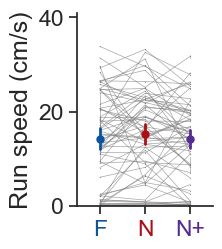

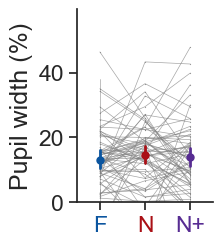

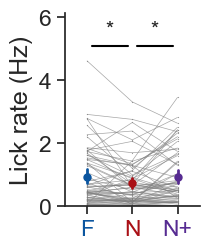

In [18]:
title = ''
#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='Run speed (cm/s)', ylims=None, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=None)


#### Pupil 

#### Changes

df = pupil_mdf_changes.copy()
df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='Pupil width (%)', ylims=None, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title=title, ax=None)


df = lick_rate_mdf_changes.copy()

df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'lick_rate', 
                                            ylabel='Lick rate (Hz)', ylims=None, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title=title, ax=None)



### Within session changes in behavior

##### Rolling d-prime using false alarm rate across stimulus presentations

In [19]:
import visual_behavior.utilities as utilities

In [20]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_stimulus_behavior_response_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


In [21]:
stim_behavior_response_df.head()

,stimulus_presentations_id,start_time,is_change,could_change,omitted,post_omitted,image_name,mean_running_speed,mean_pupil_width,lick_latency,licked,licks,reward_rate,auto_rewarded,is_image_novel,is_sham_change,epoch,behavior_session_id,mouse_id
0,1,307.176084,False,False,False,False,im065,12.685861,NaN,0.595966,True,[307.77205],1.885254,NaN,False,False,0,794968300,412036
1,2,307.926674,False,False,False,False,im065,12.339447,0.976615,0.012176,True,[307.93885],1.885254,NaN,False,False,0,794968300,412036
2,3,308.677274,False,False,False,False,im065,26.097918,0.955810,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036
3,4,309.427924,False,False,False,False,im065,30.444546,0.951674,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036
4,5,310.178494,False,False,False,False,im065,28.378029,NaN,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036


In [22]:
rolling_sdf = utilities.get_stimulus_based_rolling_performance_df_for_dataset(stim_behavior_response_df,
                                                          session_key='behavior_session_id')

# Merge with metadata 
rolling_sdf = rolling_sdf.join(platform_experiments[['behavior_session_id', 'experience_level', 'cell_type']].set_index('behavior_session_id'), on='behavior_session_id', how='left', rsuffix='_exp')

In [23]:
rolling_sdf.head()

,stimulus_presentations_id,start_time,time_in_session,is_change,licked,hit_rate_raw,hit_rate,false_alarm_rate_raw,false_alarm_rate,rolling_dprime,n_go_opportunities,n_catch_opportunities,reward_rate,behavior_session_id,experience_level,cell_type
6,7,311.917547,0.00000,True,0.0,0.000000,0.500000,NaN,NaN,NaN,1.0,0.0,inf,794071128,Familiar,Excitatory
20,21,322.426137,10.50859,True,0.0,0.000000,0.250000,NaN,NaN,NaN,2.0,0.0,inf,794071128,Familiar,Excitatory
33,34,332.184097,20.26655,True,1.0,0.333333,0.333333,NaN,NaN,NaN,3.0,0.0,inf,794071128,Familiar,Excitatory
43,44,339.690217,27.77267,True,1.0,0.500000,0.500000,NaN,NaN,NaN,4.0,0.0,inf,794071128,Familiar,Excitatory
59,60,351.699987,39.78244,True,0.0,0.400000,0.400000,NaN,NaN,NaN,5.0,0.0,1.485776,794071128,Familiar,Excitatory


In [24]:
rolling_sdf.columns

Index(['stimulus_presentations_id', 'start_time', 'time_in_session',
       'is_change', 'licked', 'hit_rate_raw', 'hit_rate',
       'false_alarm_rate_raw', 'false_alarm_rate', 'rolling_dprime',
       'n_go_opportunities', 'n_catch_opportunities', 'reward_rate',
       'behavior_session_id', 'experience_level', 'cell_type'],
      dtype='object')

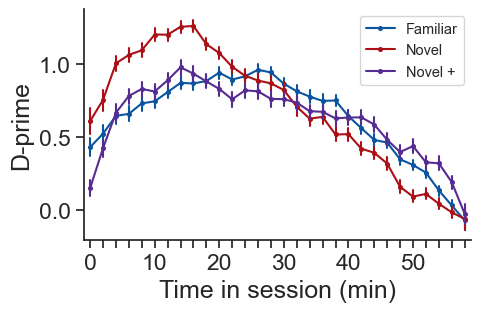

In [25]:
# rolling d-prime over time in session, in 2 min bins, x labeled in 10 min increments
ax = ppf.plot_rolling_metric_over_time_in_session(
    rolling_sdf, metric='rolling_dprime',
    bin_size_seconds=120, max_minutes=60, label_every=5,
    ylabel="D-prime", save_dir=save_dir, folder='within_session_behavior',
)

##### Pupil diameter in first 2 mins of session

##### New version of stim behavior response df

In [58]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_stimulus_behavior_response_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)

stim_behavior_response_df = stim_behavior_response_df.merge(platform_behavior_sessions[['experience_level']], on='behavior_session_id')
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


In [59]:
stim_behavior_response_df.head()

,stimulus_presentations_id,start_time,is_change,could_change,omitted,post_omitted,image_name,mean_running_speed,mean_pupil_width,lick_latency,licked,licks,reward_rate,auto_rewarded,is_image_novel,is_sham_change,epoch,behavior_session_id,mouse_id,experience_level
0,1,307.176084,False,False,False,False,im065,12.685861,NaN,0.595966,True,[307.77205],1.885254,NaN,False,False,0,794968300,412036,Familiar
1,2,307.926674,False,False,False,False,im065,12.339447,0.976615,0.012176,True,[307.93885],1.885254,NaN,False,False,0,794968300,412036,Familiar
2,3,308.677274,False,False,False,False,im065,26.097918,0.955810,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036,Familiar
3,4,309.427924,False,False,False,False,im065,30.444546,0.951674,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036,Familiar
4,5,310.178494,False,False,False,False,im065,28.378029,NaN,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036,Familiar


66


<Axes: title={'center': 'Pupil width over first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Pupil width (%)'>

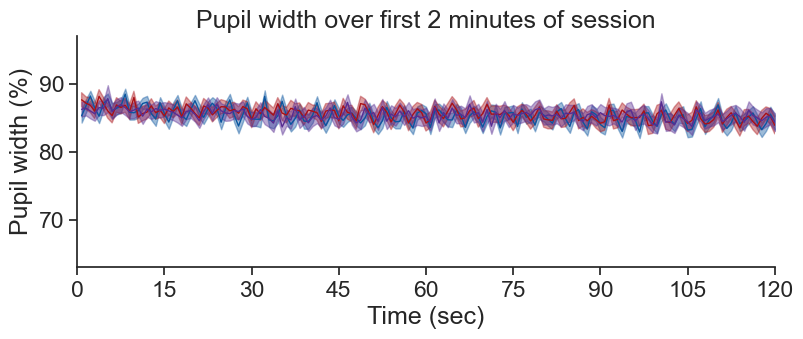

In [60]:
image_sdf = stim_behavior_response_df.reset_index()
image_sdf = image_sdf[image_sdf.is_change==False]
image_sdf = image_sdf[image_sdf.omitted==False]

# Convert to percentage of baseline                                                       
# image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] - 1
image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] * 100

# Calculate the relative stimulus_presentations_id
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'behavior_session_id']).cumcount() + 1

# Check that everything is there
print(len(image_sdf.mouse_id.unique()))

metric = 'mean_pupil_width'
ylabel = 'Pupil width (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil width over first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=None, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')



##### Original version of stim behavior response df

In [55]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_behavior_across_stimuli_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)
        
stim_behavior_response_df = stim_behavior_response_df.merge(platform_behavior_sessions[['experience_level']], on='behavior_session_id')
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


66


<Axes: title={'center': 'Pupil width over first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Pupil width (%)'>

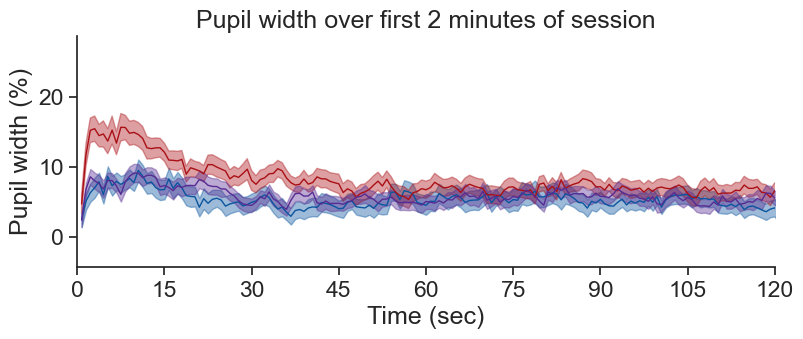

In [ ]:
image_sdf = stim_behavior_response_df.reset_index()
image_sdf = image_sdf[image_sdf.is_change==False]
image_sdf = image_sdf[image_sdf.omitted==False]

# Convert to percentage of baseline                                                       
image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] - 1
image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] * 100

# Calculate the relative stimulus_presentations_id
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'behavior_session_id']).cumcount() + 1

# Check that everything is there
print(len(image_sdf.mouse_id.unique()))


In [ ]:

metric = 'mean_pupil_width'
ylabel = 'Pupil width (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil width over first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=None, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')



### Response rate across conditions

In [29]:
data = platform_behavior_stats.copy()
print(len(data.mouse_id.unique()), 'mice')
print(len(data.behavior_session_id.unique()), 'sessions')

data = data[data.fraction_engaged>0.5]
print(len(data.mouse_id.unique()), 'mice')
print(len(data.behavior_session_id.unique()), 'sessions')


66 mice
200 sessions
64 mice
162 sessions


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:6850: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trial_types, rotation=45)


saving_stats


<Axes: ylabel='Response rate'>

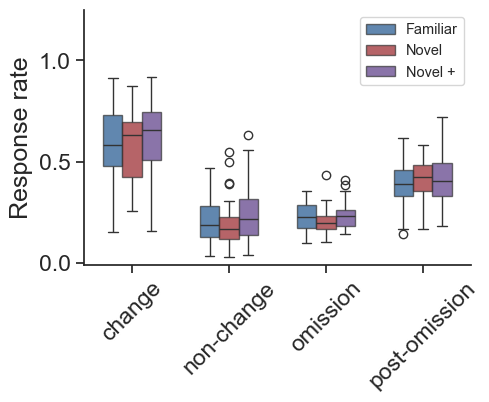

In [30]:

ppf.plot_response_rate_by_trial_type(platform_behavior_stats, metric='response_probability',
                                     fraction_engaged_thresh=0.7, ylabel='Response rate', ylims=(-0.01, 1),
                                     save_dir=save_dir, folder='behavior_metrics', ax=None)